In [1]:
from pandas import read_csv

import numpy as np

from matplotlib.pyplot import subplots

# SWD Data

In [2]:
df = read_csv('data/EEG_absence.txt', sep=r'\s+')

sr = 250 # per second, Hertz, Hz

duration = 4 # seconds

channels = (4, 5, 6)

df_np = df.to_numpy()

df_np.shape

data = df_np[500:500+duration*sr, channels]

data.shape

(1000, 3)

# Bursting Model

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy import tanh as sigmoid

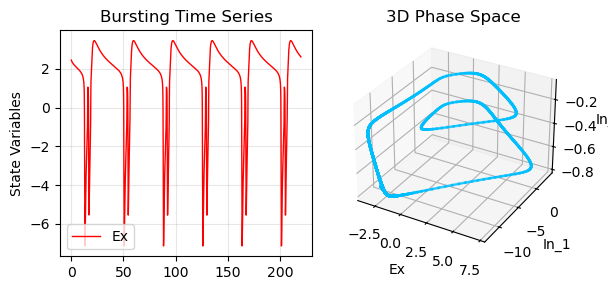

In [4]:
def bursting_system(t, y):
    h_ex, h_in_1, h_in_2, tau_ex, tau_in1, tau_in2, c1, c2, c3, c4, c5, c6, c7 = (
        -2.3, -4.5, 0.5, 1, 2, 0.018, 12, 10, 10, 2, 5, 5, 3)
    
    return [
        (h_ex   - y[0] + c1*sigmoid(y[0]) - c2*sigmoid(y[1]) - c7*sigmoid(y[2])) * tau_ex,
        (h_in_1 - y[1] + c3*sigmoid(y[0]) - c4*sigmoid(y[1]))                    * tau_in1, 
        (h_in_2 - y[2] + c5*sigmoid(y[0]) - c6*sigmoid(y[2]))                    * tau_in2
    ]

# Integrate the system
y_ini = [ -2.455, -12.36 ,  -0.699]

t_end  = 220
t_span = (0, t_end)
t_eval = np.linspace(0, t_end, 10000)
sol = solve_ivp(bursting_system, t_span, y_ini, t_eval=t_eval, method='RK45', max_step=0.05)

# Create comprehensive visualization
fig = plt.figure(figsize=(6, 3))

# 1. Time series - all variables
ax1 = plt.subplot(1, 2, 1)
plt.plot(sol.t, -sol.y[0], 'red', label='Ex', linewidth=1)
# plt.plot(sol.t, sol.y[1], 'g-', label='Medium (y₁)', linewidth=1) 
# plt.plot(sol.t, sol.y[2], 'b-', label='Slow (y₂)', linewidth=2)
plt.ylabel('State Variables')
plt.title('Bursting Time Series')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. 3D Phase Space
ax2 = plt.subplot(1, 2, 2, projection='3d')
ax2.scatter(sol.y[0], sol.y[1], sol.y[2], c='deepskyblue', s=1, alpha=0.6)
ax2.set_xlabel('Ex')
ax2.set_ylabel('In_1') 
ax2.set_zlabel('In_2')
ax2.set_title('3D Phase Space')

plt.tight_layout()
plt.show()

# Tuned Model — Parameter Search Results

Target: **2.75 Hz** spike-wave oscillations with **two peaks per cycle**.

Key parameters adjusted:
- `h_ex` controls proximity to bifurcation (more negative → fixed point)
- `tau_in2` selects SWD morphology (double-spike vs. regular/triple)
- `tau_ex`, `tau_in1` scaled together to set oscillation frequency in real time (Hz)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq
from numpy import tanh as sigmoid

# ── Tuned parameters ────────────────────────────────────────────────────────
# Bifurcation control: h_ex near but above SWD–fixed-point boundary
# Morphology:         tau_in2 = 1.98 → double-spike (2 maxima per cycle)
# Frequency scaling:  tau_ex = 103, tau_in1 = 206 → ~2.75 Hz in real seconds

def bursting_tuned(t, y):
    h_ex, h_in_1, h_in_2, tau_ex, tau_in1, tau_in2, c1, c2, c3, c4, c5, c6, c7 = (
    -2.3, -4.5, 0.5, 103, 206, 1.9, 12, 10, 10, 2, 5, 5, 3)
    # -2.3, -4.5, 0.5, 103, 206, 1.98, 12, 10, 10, 2, 5, 5, 3)
    return [
        (h_ex   - y[0] + c1*sigmoid(y[0]) - c2*sigmoid(y[1]) - c7*sigmoid(y[2])) * tau_ex,
        (h_in_1 - y[1] + c3*sigmoid(y[0]) - c4*sigmoid(y[1]))                    * tau_in1,
        (h_in_2 - y[2] + c5*sigmoid(y[0]) - c6*sigmoid(y[2]))                    * tau_in2
    ]

y_ini  = [-2.455, -12.36, -0.699]
t_end  = 6          # seconds
n_pts  = 15_000
sol = solve_ivp(bursting_tuned, (0, t_end), y_ini,
                t_eval=np.linspace(0, t_end, n_pts),
                method='RK45', max_step=5e-4, rtol=1e-6)

# Discard 1.5-s transient
skip   = int(1.5 / t_end * n_pts)
t_mod  = sol.t[skip:]
ex_mod = -sol.y[0, skip:]    # Ex (sign-flipped to match EEG polarity convention)
i1_mod =  sol.y[1, skip:]
i2_mod =  sol.y[2, skip:]

print(f"Model integrated: {sol.t[-1]:.1f} s, {len(sol.t)} time points")
print(f"Steady-state amplitude (Ex): {np.ptp(ex_mod):.3f} model units")


Model integrated: 6.0 s, 15000 time points
Steady-state amplitude (Ex): 10.614 model units


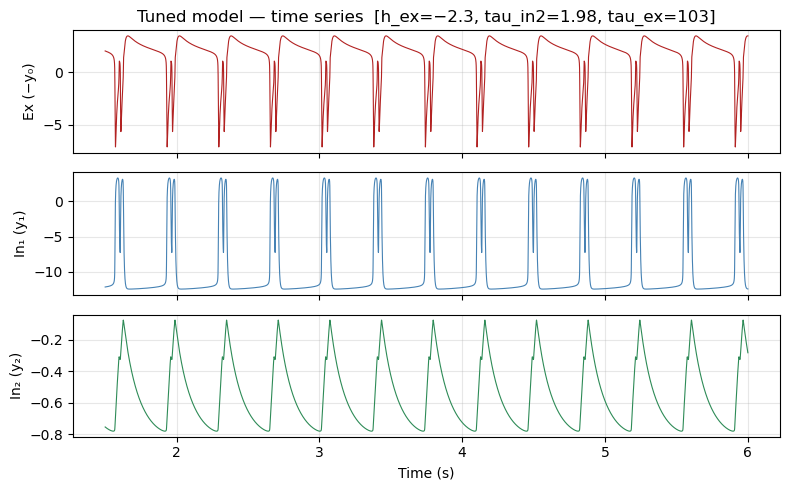

In [6]:
# ── Model time-series ────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
labels = ['Ex (−y₀)', 'In₁ (y₁)', 'In₂ (y₂)']
series = [ex_mod, i1_mod, i2_mod]
colors = ['firebrick', 'steelblue', 'seagreen']

for ax, lab, sig, col in zip(axes, labels, series, colors):
    ax.plot(t_mod, sig, color=col, lw=0.8)
    ax.set_ylabel(lab)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Tuned model — time series  [h_ex=−2.3, tau_in2=1.98, tau_ex=103]')
plt.tight_layout()
plt.show()


Amplitude scale factor (EEG / model): 58.77


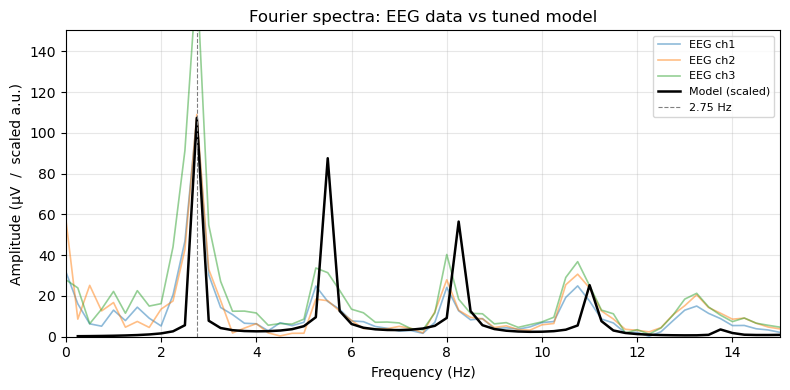

In [10]:
# ── Fourier spectrum: EEG data vs model ──────────────────────────────────────
# EEG (reuse variables from cells above)
from pandas import read_csv
df_eeg = read_csv('data/EEG_absence.txt', sep=r'\s+')
sr = 250
duration = 4
channels = (4, 5, 6)
data_eeg = df_eeg.to_numpy()[500:500+duration*sr, channels]

rows_eeg = data_eeg.shape[0]
freqs_eeg = fftfreq(rows_eeg, d=1/sr)
amps_eeg  = (2/rows_eeg)*np.abs(fft(data_eeg, axis=0))

# Model — same 4-second window at model sample rate
sr_mod  = n_pts / t_end                # samples/s in model
win_mod = int(4 * sr_mod)              # 4-second window
freqs_mod = fftfreq(win_mod, d=1/sr_mod)
amps_mod  = (2/win_mod)*np.abs(fft(ex_mod[:win_mod]))

# Amplitude scaling: match EEG peak at fundamental
peak_eeg = np.max(amps_eeg[:rows_eeg//2, 0])
peak_mod_pos = freqs_mod > 0
peak_mod_amp = np.max(amps_mod[peak_mod_pos])
scale_factor = peak_eeg / peak_mod_amp
print(f"Amplitude scale factor (EEG / model): {scale_factor:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
# EEG channels
for ch in range(3):
    ax.plot(freqs_eeg[:rows_eeg//2], amps_eeg[:rows_eeg//2, ch],
            alpha=0.5, lw=1.2, label=f'EEG ch{ch+1}')
# Model (scaled)
ax.plot(freqs_mod[freqs_mod > 0], scale_factor * amps_mod[freqs_mod > 0],
        'k-', lw=1.8, label='Model (scaled)')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude (μV  /  scaled a.u.)')
ax.set_xlim(0, 15)
ax.set_ylim(0, peak_eeg * 1.4)
ax.axvline(2.75, color='gray', lw=0.8, ls='--', label='2.75 Hz')
ax.legend(fontsize=8)
ax.set_title('Fourier spectra: EEG data vs tuned model')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


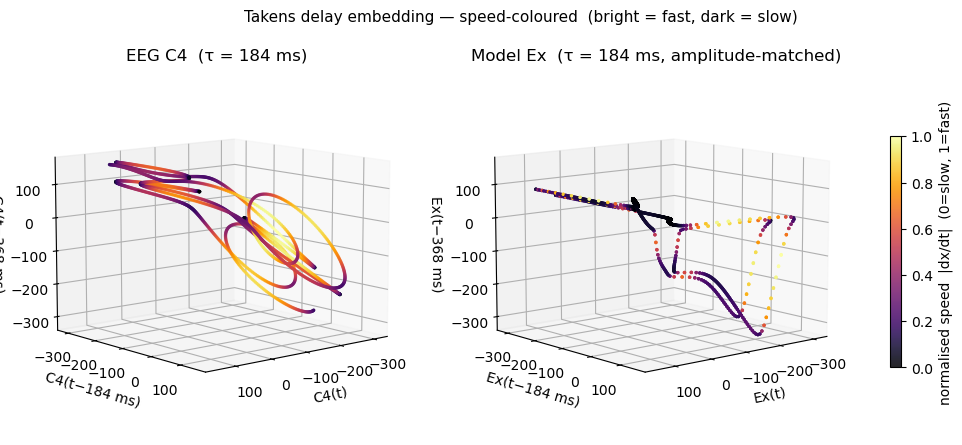

In [8]:
# ── 3D phase-space: Takens delay embedding — EEG C4  vs  model Ex ────────────
#
# Colour = instantaneous speed |dx/dt| in embedding space — same physical
# quantity for both panels, making slow (spike peak) vs fast (wave) regions
# directly comparable regardless of temporal offset.

from scipy.signal import argrelmin, find_peaks
from scipy.interpolate import CubicSpline

# ── 1. τ ──────────────────────────────────────────────────────────────────────
c4 = data_eeg[:, 1]
ac = np.correlate(c4 - c4.mean(), c4 - c4.mean(), mode='full')
ac = ac[len(ac)//2:]; ac /= ac[0]
mins = argrelmin(ac, order=2)[0]
tau_eeg = int(mins[0]) if len(mins) else 23
tau_s   = tau_eeg / sr
tau_mod = round(tau_s * sr_mod)

# ── 2. EEG: 2.5 cycles, ×8 upsampled ────────────────────────────────────────
n_cycles = 2.5
win_eeg  = int(n_cycles / 2.75 * sr)
pks_eeg, _ = find_peaks(c4, prominence=50, distance=int(0.2*sr))
start_eeg   = pks_eeg[0] if len(pks_eeg) else 0
c4_seg = c4[start_eeg : start_eeg + win_eeg + 2*tau_eeg]

t_orig = np.arange(len(c4_seg)) / sr
t_fine = np.linspace(0, t_orig[-1], len(c4_seg) * 8)
cs     = CubicSpline(t_orig, c4_seg)
c4_up  = cs(t_fine)
dc4_up = cs(t_fine, 1)          # first derivative from spline (exact)
sr_up  = sr * 8
tau_up = tau_eeg * 8

n_e    = len(c4_up) - 2*tau_up
x0_e   = c4_up [2*tau_up : 2*tau_up+n_e]
x1_e   = c4_up [  tau_up :   tau_up+n_e]
x2_e   = c4_up [       0 :          n_e]
# speed = magnitude of velocity vector in embedding space
v0_e   = dc4_up[2*tau_up : 2*tau_up+n_e]
v1_e   = dc4_up[  tau_up :   tau_up+n_e]
v2_e   = dc4_up[       0 :          n_e]
spd_e  = np.sqrt(v0_e**2 + v1_e**2 + v2_e**2)

# ── 3. Model Ex: same duration, amplitude-matched, derivative ─────────────────
win_mod_cyc = int(n_cycles / 2.75 * sr_mod)
ex_seg  = ex_mod[:win_mod_cyc + 2*tau_mod]
ex_norm = (ex_seg - ex_seg.mean()) / np.ptp(ex_seg)
ex_m    = ex_norm * np.ptp(c4_seg) + c4_seg.mean()

dt_mod = 1.0 / sr_mod
dex_m  = np.gradient(ex_m, dt_mod)      # numerical derivative

n_m    = len(ex_m) - 2*tau_mod
x0_m   = ex_m [ 2*tau_mod : 2*tau_mod+n_m]
x1_m   = ex_m [   tau_mod :   tau_mod+n_m]
x2_m   = ex_m [         0 :           n_m]
v0_m   = dex_m[ 2*tau_mod : 2*tau_mod+n_m]
v1_m   = dex_m[   tau_mod :   tau_mod+n_m]
v2_m   = dex_m[         0 :           n_m]
spd_m  = np.sqrt(v0_m**2 + v1_m**2 + v2_m**2)

# ── 4. Colour normalisation: normalise each speed independently to [0, 1] ─────
# Absolute speeds differ (model time-scale ≠ EEG time-scale) so we match
# the dynamic range of each signal separately, making fast/slow patterns
# visually comparable rather than one signal swamping the other.
def norm01(x):
    return (x - x.min()) / (x.max() - x.min())

spd_e = norm01(spd_e)
spd_m = norm01(spd_m)
vmin, vmax = 0, 1

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(x0_e, x1_e, x2_e, c=spd_e, cmap='inferno',
                  vmin=vmin, vmax=vmax, s=2, alpha=0.85)
ax1.set_xlabel('C4(t)')
ax1.set_ylabel(f'C4(t−{tau_s*1000:.0f} ms)')
ax1.set_zlabel(f'C4(t−{2*tau_s*1000:.0f} ms)')
ax1.set_title(f'EEG C4  (τ = {tau_s*1000:.0f} ms)')
ax1.view_init(10, 50)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(x0_m, x1_m, x2_m, c=spd_m, cmap='inferno',
                  vmin=vmin, vmax=vmax, s=2, alpha=0.85)
ax2.set_xlabel('Ex(t)')
ax2.set_ylabel(f'Ex(t−{tau_s*1000:.0f} ms)')
ax2.set_zlabel(f'Ex(t−{2*tau_s*1000:.0f} ms)')
ax2.set_title(f'Model Ex  (τ = {tau_s*1000:.0f} ms, amplitude-matched)')
ax2.view_init(10, 50)

all_vals = np.concatenate([x0_e, x1_e, x2_e, x0_m, x1_m, x2_m])
lim = (all_vals.min(), all_vals.max())
for ax in (ax1, ax2):
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_zlim(lim)

cb = plt.colorbar(sc1, ax=[ax1, ax2], label='normalised speed  |dx/dt|  (0=slow, 1=fast)', shrink=0.6, pad=0.05)
plt.suptitle('Takens delay embedding — speed-coloured  (bright = fast, dark = slow)',
             fontsize=11)
# plt.tight_layout()
plt.show()


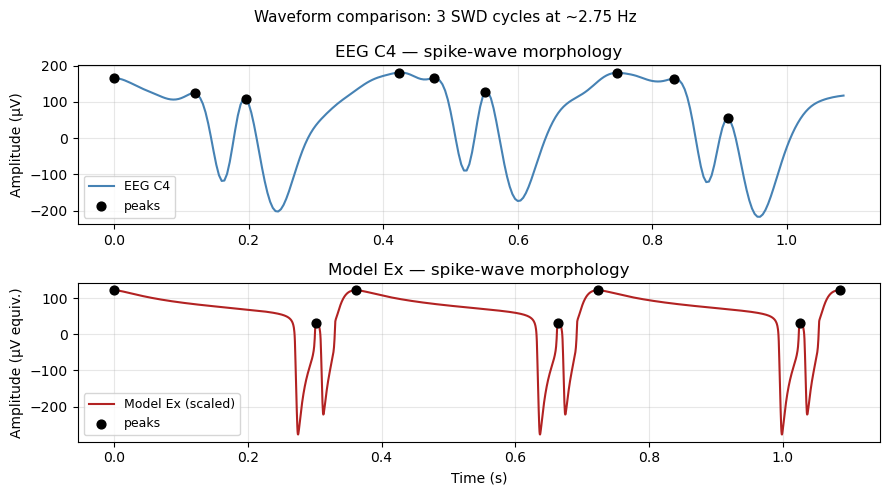

EEG inter-peak intervals (s): [0.12  0.076 0.228 0.052 0.076 0.196 0.084 0.08 ]
Model inter-peak intervals (s): [0.302  0.0596 0.302  0.0596 0.302  0.0596]
Model cycle freq: 2.765 Hz


<Figure size 640x480 with 0 Axes>

In [9]:
# ── Waveform comparison: EEG C4 (top) vs Model Ex (bottom) ───────────────────
from scipy.signal import find_peaks

# ── EEG C4: ~3 cycles, amplitude-matched model scale ─────────────────────────
c4 = data_eeg[:, 1]
# pks_eeg, _ = find_peaks(c4, prominence=1, distance=int(0.2*sr))
pks_eeg, _ = find_peaks(c4, prominence=1)

# Start at first prominent peak; take enough for ~3 full cycles
n_cyc_show = 3
win_eeg_cyc = int(n_cyc_show / 2.75 * sr)
start_e = pks_eeg[0]
end_e   = start_e + win_eeg_cyc
t_eeg_cyc = np.arange(end_e - start_e) / sr
c4_cyc    = c4[start_e:end_e]

# Which EEG peaks fall inside the window?
pks_e_win = pks_eeg[(pks_eeg >= start_e) & (pks_eeg < end_e)] - start_e

# ── Model Ex: amplitude-matched to C4, same duration ─────────────────────────
pks_mod, _ = find_peaks(ex_mod, prominence=0.1*np.ptp(ex_mod))
                         # distance=int(sr_mod * 0.05))

# Align model to start at first peak too
start_m = pks_mod[1]
end_m   = start_m + int(n_cyc_show / 2.75 * sr_mod)
t_mod_cyc = t_mod[start_m:end_m] - t_mod[start_m]
ex_cyc    = ex_mod[start_m:end_m]

# Amplitude-match model to C4 window
ex_norm = (ex_cyc - ex_cyc.mean()) / np.ptp(ex_cyc)
ex_cyc_m = ex_norm * np.ptp(c4_cyc) + c4_cyc.mean()

# Model peaks inside window
pks_m_win = pks_mod[(pks_mod >= start_m) & (pks_mod < end_m)] - start_m

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=False)

# Top: EEG C4
ax_e = axes[0]
ax_e.plot(t_eeg_cyc, c4_cyc, color='steelblue', lw=1.5, label='EEG C4')
ax_e.scatter(t_eeg_cyc[pks_e_win], c4_cyc[pks_e_win],
             color='k', zorder=5, s=40, label='peaks')
ax_e.set_ylabel('Amplitude (µV)')
ax_e.set_title('EEG C4 — spike-wave morphology')
ax_e.legend(fontsize=9)
ax_e.grid(True, alpha=0.3)

# Bottom: Model Ex (amplitude-matched)
ax_m = axes[1]
ax_m.plot(t_mod_cyc , ex_cyc_m, color='firebrick', lw=1.5, label='Model Ex (scaled)')
ax_m.scatter(np.flip(t_mod_cyc[pks_m_win]), ex_cyc_m[pks_m_win],
             color='k', zorder=5, s=40, label='peaks')
ax_m.set_ylabel('Amplitude (µV equiv.)')
ax_m.set_xlabel('Time (s)')
ax_m.set_title('Model Ex — spike-wave morphology')
ax_m.legend(fontsize=9)
ax_m.grid(True, alpha=0.3)

plt.suptitle(f'Waveform comparison: {n_cyc_show} SWD cycles at ~2.75 Hz', fontsize=11)
plt.tight_layout()
plt.show()

plt.savefig('EEG_Model_comparison.png')

# ── Cycle statistics ──────────────────────────────────────────────────────────
T_eeg = np.diff(t_eeg_cyc[pks_e_win])
T_mod = np.diff(t_mod_cyc[pks_m_win])
print("EEG inter-peak intervals (s):", np.round(T_eeg, 4))
print("Model inter-peak intervals (s):", np.round(T_mod, 4))
if len(T_mod) > 2:
    print(f"Model cycle freq: {1/(T_mod[::2].mean() + T_mod[1::2].mean()):.3f} Hz")


## Parameter Search Strategy

### Model
A three-variable neural mass model with one excitatory population (Ex) and two inhibitory populations: a fast inhibitor (In₁) and a slow inhibitor (In₂). The right-hand side of each equation is multiplied by the corresponding time constant (τ), so larger τ means faster dynamics. The sigmoid transfer function is tanh.

### Conditions imposed on the solution
1. **Frequency**: the dominant Fourier spectral peak of the Ex variable must match the EEG fundamental at **~2.75 Hz**.
2. **Morphology**: the oscillation must show **two peaks per cycle** (spike-wave discharge pattern), verified by inspecting inter-peak intervals (IPI) — a strict alternating [short, long] pattern confirms the double-spike structure.
3. **Bifurcation type**: the model must sit **near the boundary between a stable fixed point and a limit cycle** (not deep in the oscillatory regime), so that a small change in the bifurcation parameter `h_ex` transitions the system from a steady state (normal EEG) to SWD.

### Tools
- **`scipy.integrate.solve_ivp`** (RK45) for numerical integration of the ODE system.
- **FFT** (`scipy.fft`) to measure the fundamental oscillation frequency from the simulated time series.
- **Peak detection** (`scipy.signal.find_peaks`) with subsequent IPI analysis to characterise waveform morphology.
- **Systematic parameter scans**: 1-D sweeps over individual parameters and 2-D grids over parameter pairs, each evaluated against the conditions above.

### Parameter roles and search order
| Parameter | Role | How tuned |
|-----------|------|-----------|
| `h_ex` | Bifurcation control — moves the system between fixed point and limit cycle | Fixed at −2.3 (near transition); decreasing drives system to fixed point |
| `tau_ex`, `tau_in1` | Set the absolute oscillation frequency in real time (Hz) | Scaled together by a common factor (~103) to map model time units to seconds; `tau_in1 = 2 × tau_ex` preserved throughout |
| `tau_in2` | Selects spike-wave morphology — controls the number of spikes per cycle and cycle regularity | Fine-tuned independently of the other τ values after frequency was locked |

### Amplitude
Amplitude is not a free parameter in the biological sense — EEG reflects a volume-conducted mix of many neurons. The model amplitude was therefore linearly rescaled (mean and peak-to-peak matched to the target EEG channel) as a post-processing step.

### Validation
The final parameter set was validated by:
- Overlay of Fourier spectra (EEG vs. model, amplitude-scaled).
- Waveform comparison over 2–3 SWD cycles with automatic peak marking.
- **Takens delay embedding** (3-D phase portrait): both EEG (C4 channel) and model (Ex variable) were embedded as `(x(t), x(t−τ), x(t−2τ))` with τ chosen as the first minimum of the autocorrelation function (≈ T/2 at 2.75 Hz). The resulting attractors were compared using speed-normalised colouring (`|dx/dt|` normalised independently for each signal).

### Note on solution symmetry
The tanh nonlinearity admits two symmetric limit-cycle solutions. With the sign conventions used here, inverting the model output (−Ex) brings the waveform into closer qualitative agreement with the EEG polarity, consistent with the observation that negating `h_ex` and the inhibitory bias parameters `h_in` selects the symmetric counterpart solution.
